# UStar New CycleGAN-based Denoising Model Training

## CycleGAN Training Procedure

1. Create folder structure in Google Colab

In [ ]:
import os

os.makedirs("implementations/cyclegan", exist_ok=True)
os.makedirs("data", exist_ok=True)

2. Set to data folder first.

In [ ]:
%cd /content/data

/content/data


3. Upload the dataset folder as a zip

In [ ]:
# ============================================================
# REMINDER:
# Your dataset **must** follow this exact structure before upload:
#
# UStar_CycleGAN_Sample_Dataset/
# ├── train/
# │   ├── A/
# │   └── B/
# └── test/
#     ├── A/
#     └── B/
#
# Example (from your screenshot):
# UStar_CycleGAN_Sample_Dataset/train/A, UStar_CycleGAN_Sample_Dataset/train/B
# UStar_CycleGAN_Sample_Dataset/test/A,  UStar_CycleGAN_Sample_Dataset/test/B
#
# Upload the root folder (UStar_CycleGAN_Sample_Dataset.zip) containing this structure.
# ============================================================

from google.colab import files
uploaded = files.upload()

import os, shutil

# Ensure directory exists
os.makedirs("/content/data", exist_ok=True)

# Move uploaded files into /content/data
for filename in uploaded.keys():
    shutil.move(filename, f"/content/data/{filename}")

print("Uploaded files have been moved to /content/data")

KeyboardInterrupt: 

4. Unzip the dataset, feel free to change the name "UStar_CycleGAN_Sample_Dataset"  to something else

In [ ]:
!cd /content/data
!unzip ustar_real2simulated_4.zip -d ustar_real2simulated_2
!rm ustar_real2simulated_4_@.zip

5. Upload the CycleGAN source code from PC

In [ ]:
from google.colab import files
uploaded = files.upload()

# move uploaded files into the target folder
import shutil

for filename in uploaded.keys():
    shutil.move(filename, "/content/implementations/cyclegan/" + filename)

print("Files uploaded to /content/implementations/cyclegan/")

6. Show an image with transformations applied in CycleGAN dataset

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch

# -----------------------------
# Dataset paths (adjust if needed)
# -----------------------------
ROOT = "/content/data/ustar_real2simulated_2/ustar_real2simulated_4/train"
PATH_A = os.path.join(ROOT, "A")
PATH_B = os.path.join(ROOT, "B")

# -----------------------------
# Define transforms (EXACT training transforms)
# -----------------------------
IMG_H, IMG_W = 256, 256

# Image transformations
transforms_ = [
    transforms.Resize(int(256 * 1.12), Image.BICUBIC),
    transforms.RandomCrop((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
]

transform_pipeline = transforms.Compose(transforms_)

# -----------------------------
# Print transform pipeline
# -----------------------------
print("=== CycleGAN Transform Pipeline ===")
for i, t in enumerate(transform_pipeline.transforms):
    print(f"{i+1}. {t}")

# -----------------------------
# Helper to visualize images
# -----------------------------
def show_samples(folder, title):
    files = random.sample(
        [f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))],
        5
    )

    fig, axes = plt.subplots(5, 2, figsize=(6, 12))
    fig.suptitle(title, fontsize=14)

    for i, fname in enumerate(files):
        img_path = os.path.join(folder, fname)
        img = Image.open(img_path).convert("RGB")

        # Apply transform
        tensor = transform_pipeline(img)

        # Unnormalize for display
        disp = (tensor * 0.5 + 0.5).clamp(0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(disp.permute(1, 2, 0))
        axes[i, 1].set_title("After Transform")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Show samples from both domains
# -----------------------------
show_samples(PATH_A, "Domain A (Real)")
show_samples(PATH_B, "Domain B (Simulated)")

7. Run the CycleGAN code

In [ ]:
# --epoch                 : Epoch to start training from (0 = fresh training)
# --n_epochs              : Total number of epochs to train
# --dataset_name          : Name of the dataset folder (must include trainA/trainB and testA/testB)
# --batch_size            : Number of images per batch
# --lr                    : Learning rate for Adam optimizer
# --b1                    : Adam optimizer beta1 (momentum term)
# --b2                    : Adam optimizer beta2 (momentum term)
# --decay_epoch           : Epoch when learning rate decay begins
# --n_cpu                 : Number of CPU threads for data loading
# --img_height            : Input image height
# --img_width             : Input image width
# --channels              : Image channels (3 = RGB)
# --sample_interval       : Save generated images every N batches
# --checkpoint_interval   : Save model checkpoints every N epochs (-1 disables saving)
# --n_residual_blocks     : Number of ResNet residual blocks in the generator
# --lambda_cyc            : Weight for cycle-consistency loss
# --lambda_id             : Weight for identity loss (0 = disable identity loss)
# Note: The dataset is located in "/content/data/ustar_real2simulated_2/ustar_real2simulated_3"

# Set the directory
!cd /content/implementations/cyclegan

# Run the source code
!python3 /content/implementations/cyclegan/cyclegan.py \
--epoch 0 \
--n_epochs 250 \
--decay_epoch 125 \
--batch_size 1 \
--lr 0.0002 \
--b1 0.5 \
--b2 0.999 \
--img_height 256 \
--img_width 256 \
--channels 3 \
--n_residual_blocks 9 \
--lambda_cyc 10.0 \
--lambda_id 5.0 \
--sample_interval 100 \
--checkpoint_interval 1

Namespace(epoch=0, n_epochs=250, dataset_name='monet2photo', batch_size=1, lr=0.0002, b1=0.5, b2=0.999, decay_epoch=125, n_cpu=8, img_height=256, img_width=256, channels=3, sample_interval=100, checkpoint_interval=1, n_residual_blocks=9, lambda_cyc=10.0, lambda_id=5.0)

Please enter the FULL dataset path (folder containing train/ and test/):
Dataset path: /content/data/ustar_real2simulated_2/ustar_real2simulated_4
Using dataset path: /content/data/ustar_real2simulated_2/ustar_real2simulated_4
>>> #Train Images: 800
>>> #Test Images: 200
/content/implementations/cyclegan/cyclegan.py:198: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  valid = Variable(Tensor(np.ones((real_A.size(0), *D_A.output_shape))), requires_grad=False)
[Epoch 111/250] [Batch 676/800] [D loss: 0.029842] [G loss: 1

8. Display generated images to users.

Enter the dataset name (the folder inside images/): /content/data/images/monet2photo
Showing: /content/data/images/monet2photo/9900.png


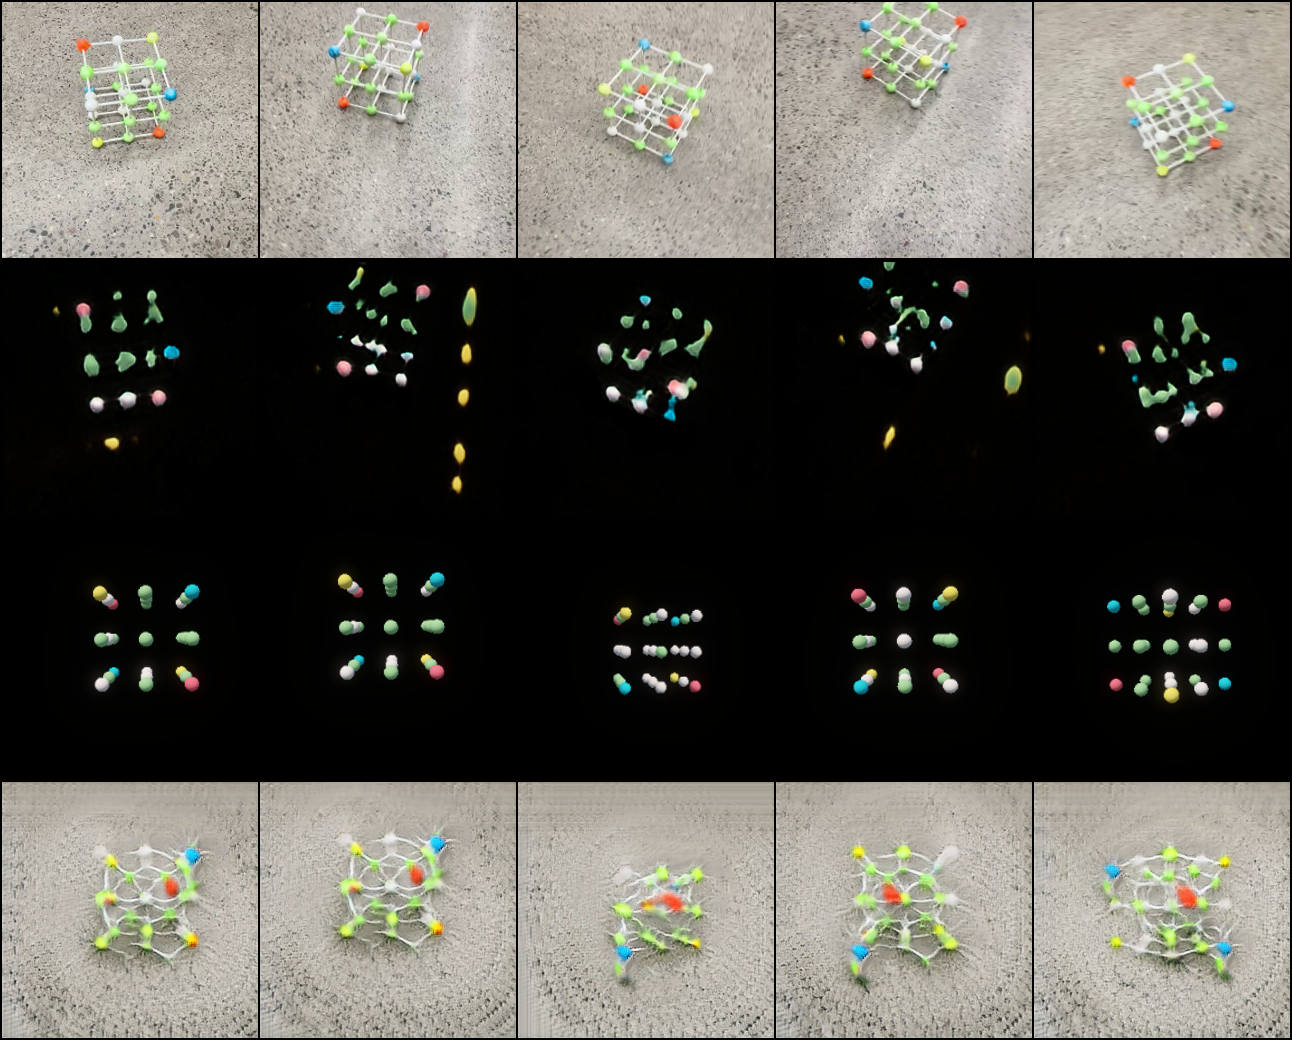

In [ ]:
import glob
import os
from IPython.display import Image, display

# Ask user for dataset folder name
user_ds = input("Enter the dataset name (the folder inside images/): ").strip()

sample_dir = os.path.join("images", user_ds)
pngs = sorted(glob.glob(os.path.join(sample_dir, "*.png")))

if not pngs:
    print(f"No PNG samples found in: {sample_dir}")
else:
    latest_sample = pngs[-1]
    print("Showing:", latest_sample)
    display(Image(filename=latest_sample))

9. Install torch.fidelity library

In [ ]:
!pip -q install torch-fidelity

10. Load each .pth file between the given epoch range

In [33]:
import os, glob, sys, torch

# ---------- CONFIG ----------
SAVED_MODELS  = "/content/data/saved_models/monet2photo"
EPOCH_MIN, EPOCH_MAX = 70, 111   # set your range
CYCLEGAN_ROOT = "/content/implementations/cyclegan"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ----------------------------

if CYCLEGAN_ROOT not in sys.path:
    sys.path.append(CYCLEGAN_ROOT)
from models import GeneratorResNet

# Must match training
channels, H, W, n_blocks = 3, 256, 256, 9
input_shape = (channels, H, W)

def epoch_from_ckpt(path):
    # G_AB_27.pth -> 27
    base = os.path.splitext(os.path.basename(path))[0]
    try:
        return int(base.split("_")[-1])
    except:
        return None

# Detect epochs that exist
g_ab_files = glob.glob(os.path.join(SAVED_MODELS, "G_AB_*.pth"))
epochs_all = sorted({epoch_from_ckpt(p) for p in g_ab_files if epoch_from_ckpt(p) is not None})
epochs = [e for e in epochs_all if EPOCH_MIN <= e <= EPOCH_MAX]

print("SAVED_MODELS:", SAVED_MODELS)
print("All epochs found (sample):", epochs_all[:30], "..." if len(epochs_all) > 30 else "")
print(f"Epochs to OPEN in range {EPOCH_MIN}-{EPOCH_MAX}:", epochs)

if not epochs:
    raise RuntimeError("No G_AB_*.pth found in that epoch range. Change range or folder.")

# Try loading each checkpoint
ok, failed = [], []
dummy = torch.randn(1, channels, H, W, device=DEVICE)

for epoch in epochs:
    ckpt_path = os.path.join(SAVED_MODELS, f"G_AB_{epoch}.pth")
    try:
        state = torch.load(ckpt_path, map_location="cpu")

        G_AB = GeneratorResNet(input_shape, n_blocks).to(DEVICE)
        G_AB.load_state_dict(state)
        G_AB.eval()

        with torch.inference_mode():
            out = G_AB(dummy)

        ok.append(epoch)
        print(f"✅ Epoch {epoch}: loaded + forward OK | out shape {tuple(out.shape)}")

    except Exception as e:
        failed.append((epoch, str(e)))
        print(f"❌ Epoch {epoch}: FAILED to load/forward -> {e}")

    finally:
        if "G_AB" in locals():
            del G_AB
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

print("\nSummary:")
print("  OK epochs:", ok)
print("  Failed epochs:", [e for e,_ in failed])

SAVED_MODELS: /content/data/saved_models/monet2photo
All epochs found (sample): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29] ...
Epochs to OPEN in range 70-111: [70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
✅ Epoch 70: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 71: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 72: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 73: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 74: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 75: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 76: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 77: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 78: loaded + forward OK | out shape (1, 3, 256, 256)
✅ Epoch 79: loaded + forward OK | out shape (1, 

11. Compute FID Scores

In [34]:
# ---- FID "accuracy" evaluation for ok epochs ----
!pip -q install torch-fidelity
from torch_fidelity import calculate_metrics
import torchvision.transforms as T
from PIL import Image
import numpy as np
import glob, os

DATA_ROOT  = "/content/data/ustar_real2simulated_2/ustar_real2simulated_4"
EVAL_SPLIT = "test"
MAX_EVAL_IMAGES = 200

# preprocessing (no random aug during eval)
eval_tf = T.Compose([
    T.Resize((H, W), interpolation=Image.BICUBIC),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3),
])

def load_img_eval(path):
    return eval_tf(Image.open(path).convert("RGB")).unsqueeze(0)

def list_imgs(folder, limit=200):
    exts = ("*.png","*.jpg","*.jpeg","*.bmp","*.webp","*.PNG","*.JPG","*.JPEG")
    files = []
    for e in exts:
        files += glob.glob(os.path.join(folder, e))
    return sorted(files)[:limit]

A_dir = os.path.join(DATA_ROOT, EVAL_SPLIT, "A")
B_dir = os.path.join(DATA_ROOT, EVAL_SPLIT, "B")

A_paths = list_imgs(A_dir, MAX_EVAL_IMAGES)
B_paths = list_imgs(B_dir, MAX_EVAL_IMAGES)

print("\nEval images:")
print(" A:", len(A_paths), "from", A_dir)
print(" B:", len(B_paths), "from", B_dir)
assert A_paths and B_paths, "No eval images found in A/B"

# folder for real B (torch-fidelity needs folders)
realB_dir = f"/content/realB_eval_{EVAL_SPLIT}"
os.makedirs(realB_dir, exist_ok=True)
for f in glob.glob(os.path.join(realB_dir, "*.png")):
    os.remove(f)
for i, p in enumerate(B_paths):
    Image.open(p).convert("RGB").save(os.path.join(realB_dir, f"{i:05d}.png"))

fid_results = []  # (epoch, fid)

for epoch in ok:
    ckpt_path = os.path.join(SAVED_MODELS, f"G_AB_{epoch}.pth")
    print(f"\nEpoch {epoch}: computing FID...")

    # load model
    G_AB = GeneratorResNet(input_shape, n_blocks).to(DEVICE)
    G_AB.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    G_AB.eval()

    fake_dir = f"/content/fakeB_epoch_{epoch}"
    os.makedirs(fake_dir, exist_ok=True)
    for f in glob.glob(os.path.join(fake_dir, "*.png")):
        os.remove(f)

    with torch.inference_mode():
        for i, pA in enumerate(A_paths):
            x = load_img_eval(pA).to(DEVICE)
            y = G_AB(x)

            # tensor [-1,1] -> uint8 RGB
            img = ((y[0] + 1) * 127.5).clamp(0,255).byte()
            img = img.permute(1,2,0).cpu().numpy()
            Image.fromarray(img).save(os.path.join(fake_dir, f"{i:05d}.png"))

    fid = float(calculate_metrics(
        input1=fake_dir,
        input2=realB_dir,
        fid=True, isc=False, kid=False,
        cuda=(DEVICE=="cuda"),
        verbose=False
    )["frechet_inception_distance"])

    fid_results.append((epoch, fid))
    print(f"Epoch {epoch:3d} | FID {fid:8.3f}")

    del G_AB
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

# Print and pick best
fid_results.sort(key=lambda x: x[0])

print("\n📊 FID RESULTS (lower = better, accuracy-like)")
print("Epoch |   FID")
print("-" * 18)
for e, fid in fid_results:
    print(f"{e:5d} | {fid:7.3f}")

BEST_EPOCH, BEST_FID = min(fid_results, key=lambda x: x[1])
print("\n🏆 BEST EPOCH:", BEST_EPOCH, "| BEST FID:", BEST_FID)


Eval images:
 A: 200 from /content/data/ustar_real2simulated_2/ustar_real2simulated_4/test/A
 B: 200 from /content/data/ustar_real2simulated_2/ustar_real2simulated_4/test/B

Epoch 70: computing FID...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 34.8MB/s]
/usr/local/lib/python3.12/dist-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)


Epoch  70 | FID  142.140

Epoch 71: computing FID...
Epoch  71 | FID  122.591

Epoch 72: computing FID...
Epoch  72 | FID  127.965

Epoch 73: computing FID...
Epoch  73 | FID  131.884

Epoch 74: computing FID...
Epoch  74 | FID  120.305

Epoch 75: computing FID...
Epoch  75 | FID  132.883

Epoch 76: computing FID...
Epoch  76 | FID  136.759

Epoch 77: computing FID...
Epoch  77 | FID  121.912

Epoch 78: computing FID...
Epoch  78 | FID  124.195

Epoch 79: computing FID...
Epoch  79 | FID  120.372

Epoch 80: computing FID...
Epoch  80 | FID  141.656

Epoch 81: computing FID...
Epoch  81 | FID  143.383

Epoch 82: computing FID...
Epoch  82 | FID  129.244

Epoch 83: computing FID...
Epoch  83 | FID  123.273

Epoch 84: computing FID...
Epoch  84 | FID  122.789

Epoch 85: computing FID...
Epoch  85 | FID  124.748

Epoch 86: computing FID...
Epoch  86 | FID  132.045

Epoch 87: computing FID...
Epoch  87 | FID  129.136

Epoch 88: computing FID...
Epoch  88 | FID  123.823

Epoch 89: computing 

12. Download ONLY the best .pth and phone-optimized .ptl

In [35]:
import os
import torch
from torch.utils.mobile_optimizer import optimize_for_mobile
from google.colab import files

# ---- pick best epoch by fidelity (FID) ----
# assumes fid_results = [(epoch, fid), ...] exists from the evaluation cell
if "BEST_EPOCH" not in globals():
    BEST_EPOCH, BEST_FID = min(fid_results, key=lambda x: x[1])
    print("🏆 BEST_EPOCH (lowest FID):", BEST_EPOCH, "| FID:", BEST_FID)

# Rebuild generator (must match training)
G_AB = GeneratorResNet((3,256,256), 9).cpu()
pth_path = os.path.join(SAVED_MODELS, f"G_AB_{BEST_EPOCH}.pth")

# Load weights
G_AB.load_state_dict(torch.load(pth_path, map_location="cpu"))
G_AB.eval()
for p in G_AB.parameters():
    p.requires_grad_(False)

example = torch.randn(1, 3, 256, 256)

# Script/trace
with torch.inference_mode():
    try:
        ts = torch.jit.script(G_AB)
        print("Used torch.jit.script")
    except Exception as e:
        print("torch.jit.script failed -> trace:", e)
        ts = torch.jit.trace(G_AB, example)

# Freeze (good practice for mobile)
try:
    ts = torch.jit.freeze(ts)
    print("torch.jit.freeze: OK")
except Exception as e:
    print("torch.jit.freeze skipped:", e)

# Mobile optimize
ts_opt = optimize_for_mobile(ts)

# Save Android Lite model (.ptl)
os.makedirs("/content/best_model", exist_ok=True)
ptl_path = f"/content/best_model/G_AB_{BEST_EPOCH}_mobile.ptl"
ts_opt._save_for_lite_interpreter(ptl_path)

print("\nSaved Lite model:", ptl_path)

# Quick sanity test: load + forward
with torch.inference_mode():
    m = torch.jit.load(ptl_path)
    y = m(example)
print("✅ PTL forward OK. Output shape:", tuple(y.shape))

print("\n⬇️ Downloading files:")
print(" -", pth_path)
print(" -", ptl_path)

files.download(pth_path)   # raw checkpoint
files.download(ptl_path)   # Android-compatible PyTorch Lite model

Used torch.jit.script
torch.jit.freeze: OK

Saved Lite model: /content/best_model/G_AB_93_mobile.ptl
✅ PTL forward OK. Output shape: (1, 3, 256, 256)

⬇️ Downloading files:
 - /content/data/saved_models/monet2photo/G_AB_93.pth
 - /content/best_model/G_AB_93_mobile.ptl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>